# E-Commerce Shopper Behavior Clustering

**Objective:** Segment anonymous shopping sessions by engagement, basket activity, discount use, and purchase cadence.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["pages_viewed", "session_minutes", "cart_events", "discount_pct", "days_since_visit", "prior_orders"]
PROFILE_CENTERS = {
  "browsers": [
    14,
    9,
    1,
    5,
    21,
    1
  ],
  "deal_seekers": [
    24,
    18,
    5,
    28,
    8,
    4
  ],
  "loyal_buyers": [
    18,
    13,
    6,
    8,
    3,
    18
  ],
  "high_intent": [
    35,
    27,
    10,
    12,
    2,
    8
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,pages_viewed,session_minutes,cart_events,discount_pct,days_since_visit,prior_orders,generator_profile
0,23.063,10.778,5.557,7.507,2.745,16.060,loyal_buyers
1,13.084,9.385,0.981,5.164,21.760,1.132,browsers
2,18.886,12.193,5.051,7.404,2.984,20.098,loyal_buyers
3,24.014,18.807,5.583,32.613,8.248,4.236,deal_seekers
4,14.660,8.520,0.959,5.681,18.815,0.759,browsers


,count,mean,std,min,25%,50%,75%,max
pages_viewed,492.0,22.769,8.446,9.850,15.660,20.247,28.757,43.862
session_minutes,492.0,16.625,6.992,6.977,10.533,14.801,20.720,35.261
cart_events,500.0,5.467,3.267,0.772,3.078,5.328,7.619,12.767
discount_pct,500.0,13.308,9.101,3.718,6.135,9.341,16.302,35.866
days_since_visit,500.0,8.477,7.619,1.447,2.399,5.015,11.365,26.287
prior_orders,500.0,7.709,6.412,0.743,2.436,5.436,10.621,23.057


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=4 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.5387,0.5863
1,3,0.6279,0.6198
2,4,0.7917,0.3252
3,5,0.6779,0.7519
4,6,0.5512,1.0299


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.7917,0.3252
1,Agglomerative,0.7917,0.3252


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 1.0000


,records,pages_viewed,session_minutes,cart_events,discount_pct,days_since_visit,prior_orders
cluster,,,,,,,
0,125,13.882,8.937,1.003,4.999,20.903,0.989
1,125,35.271,26.923,9.972,12.112,2.010,8.085
2,125,24.086,18.031,4.951,28.149,8.023,4.011
3,125,17.641,12.909,5.942,7.970,2.972,17.753


cluster,0,1,2,3,All
generator_profile,,,,,
browsers,125,0,0,0,125
deal_seekers,0,0,125,0,125
high_intent,0,125,0,0,125
loyal_buyers,0,0,0,125,125
All,125,125,125,125,500


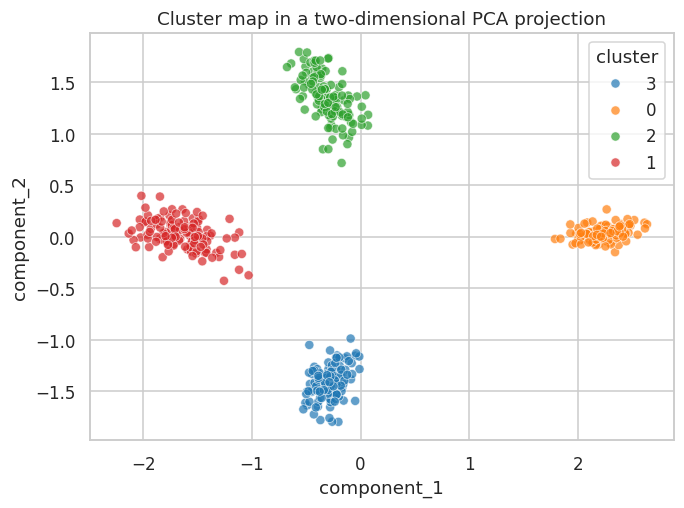

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,pages_viewed,session_minutes,cart_events,discount_pct,days_since_visit,prior_orders,predicted_cluster
0,20.247,14.801,5.328,9.341,5.015,5.436,3


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
